# ServiFlow — Notebook complet (segmentation & churn)

**Objectif pédagogique :** dérouler une démarche *end-to-end* rigoureuse (EDA + DQM → segmentation → modélisation churn) en gardant un **fil conducteur business**.

Ce notebook suit le brief : segmentation opérationnelle, comparaison de 3/4/5 segments, construction d’une cible de churn à horizon 6 mois, traitement des valeurs manquantes et outliers, recommandations.


## 0) Pré-requis et cadre méthodologique

**Contexte :** SaaS B2B en abonnement mensuel (MRR), usage, support, satisfaction, retards de paiement.

**Livrables attendus (traduction data → décision) :**
- une segmentation clients exploitable (marketing / customer success / support)
- une lecture churn (signaux précurseurs)
- un modèle supervisé de scoring churn (baseline linéaire puis modèles non-linéaires)
- une synthèse actionnable (priorités et leviers)

> **Point d’attention majeur** : *data leakage* (fuite d’information). Toute variable qui « sait » déjà le churn futur (ex : statut Résilié, date_fin_abonnement) doit être **exclue** des features au mois d’observation.


In [34]:
import sys, struct
print(sys.executable)
print("bits:", struct.calcsize("P")*8)


/Users/draux/Github - davidraux-iut-nanterre/jedha/.venv/bin/python
bits: 64


In [35]:
# Imports — environnement data science standard
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# sklearn (préprocessing + modèles + évaluation)
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Baselines
from sklearn.linear_model import Ridge, LogisticRegression

# Modèles non-linéaires
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import cross_val_score, GridSearchCV

# Metrics
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

# (import demandé dans l'énoncé — utile en régression, mais ici on fera surtout de la classification)
from sklearn.metrics import r2_score

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Feature importance
from sklearn.inspection import permutation_importance

# XGBoost
from xgboost import XGBClassifier

sns.set_context('notebook')


## 1) Chargement des données (modèle en étoile)

Nous disposons :
- `fact_abonnement_mensuel` (grain client × mois) : MRR, usage, support, satisfaction, retards
- `dim_client` : secteur, pays, taille, dates d’abonnement
- `dim_offre` : offre, SLA, prix
- `dim_date` : calendrier mensuel

### 1.1 Lecture et typage


In [36]:
dim_client = pd.read_csv('dim_client.csv')
dim_offre  = pd.read_csv('dim_offre.csv')
dim_date   = pd.read_csv('dim_date.csv')
fact       = pd.read_csv('fact_abonnement_mensuel.csv')

# Typage dates
dim_client['date_debut_abonnement'] = pd.to_datetime(dim_client['date_debut_abonnement'])
dim_client['date_fin_abonnement']   = pd.to_datetime(dim_client['date_fin_abonnement'], errors='coerce')
dim_date['date_mois']               = pd.to_datetime(dim_date['date_mois'])

print('Shapes')
print('dim_client:', dim_client.shape)
print('dim_offre :', dim_offre.shape)
print('dim_date  :', dim_date.shape)
print('fact      :', fact.shape)

display(dim_client.head(3))
display(dim_offre)
display(dim_date.head(3))
display(fact.head(3))


Shapes
dim_client: (1800, 9)
dim_offre : (4, 6)
dim_date  : (18, 6)
fact      : (27219, 10)


,id_client,nom_client,secteur_activite,pays,nb_employes,date_debut_abonnement,segment_reference,date_fin_abonnement,statut_abonnement
0,7853b304-616f-4ec7-be40-8f73e21a119a,Groupe Barthelemy Médical,Santé,France,4369,2024-02-01,C_grands_comptes_sous_exploites,2024-10-31,Résilié
1,cf8f8de0-8c92-41e1-a108-08d8e2a3da4a,Data Société Jacob SA,Informatique,France,201,2024-01-01,B_PME_en_croissance,NaT,Actif
2,507be6db-8413-438b-a714-f9c606f95ece,Territory Grupo Juan Antonio Viña Barón S.Com.,Secteur public,Espagne,8663,2022-11-01,D_grands_comptes_strategiques,2024-10-31,Résilié


,id_offre,nom_offre,niveau_sla,prix_mensuel_base_eur,prix_par_licence_eur,remise_volume_max_pct
0,1,Essentiel,Standard,220,25,0.10
1,2,Pro,Étendu,520,55,0.12
2,3,Entreprise,24/7,1500,85,0.15
3,4,Sur-mesure,24/7,2600,120,0.18


,id_date,date_mois,annee,mois,nom_mois,trimestre
0,202401,2024-01-01,2024,1,janvier,1
1,202402,2024-02-01,2024,2,février,1
2,202403,2024-03-01,2024,3,mars,1


,id_client,id_offre,id_date,mrr_eur,nb_licences,heures_utilisation,nb_tickets_support,nb_escalades,score_satisfaction,indicateur_retard_paiement
0,7853b304-616f-4ec7-be40-8f73e21a119a,3,202402,19355.367928,263,337.930475,13,3,2.855662,0
1,7853b304-616f-4ec7-be40-8f73e21a119a,3,202403,19040.871778,231,448.710714,20,1,3.351230,0
2,7853b304-616f-4ec7-be40-8f73e21a119a,3,202404,16668.172154,233,727.829216,28,1,2.790450,1


### 1.2 Construction de la vue analytique (join fact + dimensions)

On crée une table « wide » pour l’EDA et les modèles.


In [37]:
df = (fact
      .merge(dim_client, on='id_client', how='left')
      .merge(dim_offre,  on='id_offre', how='left')
      .merge(dim_date,   on='id_date', how='left'))

print('df shape:', df.shape)
display(df.head())


df shape: (27219, 28)


,id_client,id_offre,id_date,mrr_eur,nb_licences,heures_utilisation,nb_tickets_support,nb_escalades,score_satisfaction,indicateur_retard_paiement,...,nom_offre,niveau_sla,prix_mensuel_base_eur,prix_par_licence_eur,remise_volume_max_pct,date_mois,annee,mois,nom_mois,trimestre
0,7853b304-616f-4ec7-be40-8f73e21a119a,3,202402,19355.367928,263,337.930475,13,3,2.855662,0,...,Entreprise,24/7,1500,85,0.15,2024-02-01,2024,2,février,1
1,7853b304-616f-4ec7-be40-8f73e21a119a,3,202403,19040.871778,231,448.710714,20,1,3.351230,0,...,Entreprise,24/7,1500,85,0.15,2024-03-01,2024,3,mars,1
2,7853b304-616f-4ec7-be40-8f73e21a119a,3,202404,16668.172154,233,727.829216,28,1,2.790450,1,...,Entreprise,24/7,1500,85,0.15,2024-04-01,2024,4,avril,2
3,7853b304-616f-4ec7-be40-8f73e21a119a,3,202405,19370.865742,239,411.809560,11,3,4.462222,1,...,Entreprise,24/7,1500,85,0.15,2024-05-01,2024,5,mai,2
4,7853b304-616f-4ec7-be40-8f73e21a119a,3,202406,21000.866725,243,328.464169,12,0,3.987168,0,...,Entreprise,24/7,1500,85,0.15,2024-06-01,2024,6,juin,2


## 2) Étape 1 — EDA de découverte & DQM (Data Quality Management)

Objectif : comprendre la structure et **sécuriser** la qualité avant toute analyse.

Nous allons vérifier :
1. Intégrité référentielle (FK → dimensions)
2. Duplicats (grain annoncé : client × mois)
3. Valeurs manquantes
4. Valeurs atypiques (outliers)


In [38]:
# 2.1 Intégrité référentielle
missing_client = fact.loc[~fact['id_client'].isin(dim_client['id_client']), 'id_client'].nunique()
missing_offre  = fact.loc[~fact['id_offre'].isin(dim_offre['id_offre']),   'id_offre'].nunique()
missing_date   = fact.loc[~fact['id_date'].isin(dim_date['id_date']),     'id_date'].nunique()

print('Valeurs FK absentes des dimensions :')
print(' - id_client manquants :', missing_client)
print(' - id_offre  manquants :', missing_offre)
print(' - id_date   manquants :', missing_date)


Valeurs FK absentes des dimensions :
 - id_client manquants : 0
 - id_offre  manquants : 0
 - id_date   manquants : 0


In [39]:
# 2.2 Duplicats au grain client × mois
n_total = fact.shape[0]
n_unique = fact[['id_client', 'id_date']].drop_duplicates().shape[0]
print('Lignes fact :', n_total)
print('Couples (id_client, id_date) uniques :', n_unique)
print('Duplicats (si >0 : à investiguer) :', n_total - n_unique)


Lignes fact : 27219
Couples (id_client, id_date) uniques : 27219
Duplicats (si >0 : à investiguer) : 0


Colonnes avec manquants (%):


,missing_pct
date_fin_abonnement,89.28
heures_utilisation,3.00
score_satisfaction,3.00
mrr_eur,2.00


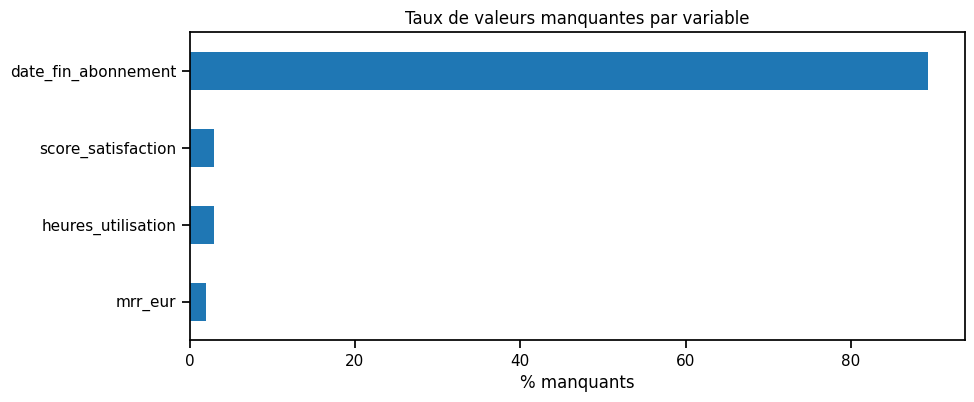

In [40]:
# 2.3 Valeurs manquantes
missing = (df.isna().mean()*100).sort_values(ascending=False)
missing = missing[missing>0]
print('Colonnes avec manquants (%):')
display(missing.to_frame('missing_pct').round(2))

# Visualisation
plt.figure(figsize=(10,4))
missing.sort_values().plot(kind='barh')
plt.title('Taux de valeurs manquantes par variable')
plt.xlabel('% manquants')
plt.show()


In [41]:
# 2.4 Statistiques descriptives (numériques)
num_cols = [
    'mrr_eur','nb_licences','heures_utilisation','nb_tickets_support','nb_escalades',
    'score_satisfaction','indicateur_retard_paiement','nb_employes',
    'prix_mensuel_base_eur','prix_par_licence_eur','remise_volume_max_pct'
]

display(df[num_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
mrr_eur,26675.0,30487.653878,65238.189594,150.0,658.529381,3826.458904,25115.743084,672415.064155
nb_licences,27219.0,346.087623,698.706045,1.0,11.000000,64.000000,310.000000,4690.000000
heures_utilisation,26403.0,880.949380,2102.396064,0.0,22.886760,128.109412,511.299888,24952.797929
nb_tickets_support,27219.0,32.560601,72.635975,0.0,2.000000,6.000000,21.000000,812.000000
nb_escalades,27219.0,0.954039,1.369866,0.0,0.000000,0.000000,2.000000,11.000000
score_satisfaction,26403.0,4.180190,2.441592,0.0,2.516274,4.908664,6.021425,10.000000
indicateur_retard_paiement,27219.0,0.223741,0.416758,0.0,0.000000,0.000000,0.000000,1.000000
nb_employes,27219.0,1467.738455,2247.637024,5.0,58.000000,245.000000,2351.000000,8999.000000
prix_mensuel_base_eur,27219.0,1037.680297,861.052223,220.0,220.000000,520.000000,1500.000000,2600.000000
prix_par_licence_eur,27219.0,65.107094,33.269421,25.0,25.000000,55.000000,85.000000,120.000000


### 2.5 Outliers — approche robuste (IQR)

Dans un contexte SaaS B2B, des valeurs très élevées (MRR, heures, tickets) peuvent être :
- **réelles** (grands comptes)
- **anormales** (erreur de saisie / capteurs / agrégation)

On ne « supprime » pas par réflexe : on **diagnostique** et on justifie le traitement (winsorisation, log, modèles robustes).


,variable,iqr_low,iqr_high,outlier_rate
0,mrr_eur,-36027.291174,61801.563639,0.132446
1,heures_utilisation,-709.732932,1243.919580,0.156800
2,nb_tickets_support,-26.500000,49.500000,0.152614
3,nb_licences,-437.500000,758.500000,0.127448


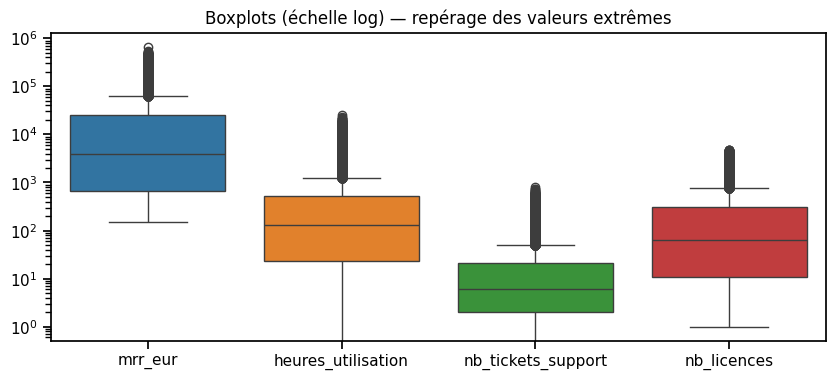

In [42]:
def iqr_outliers(s: pd.Series):
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return lo, hi, ((s < lo) | (s > hi)).mean()

outlier_report = []
for c in ['mrr_eur','heures_utilisation','nb_tickets_support','nb_licences']:
    lo, hi, pct = iqr_outliers(df[c])
    outlier_report.append((c, lo, hi, pct))

outlier_df = pd.DataFrame(outlier_report, columns=['variable','iqr_low','iqr_high','outlier_rate'])
display(outlier_df)

# Boxplots (log scale pour lisibilité)
plt.figure(figsize=(10,4))
sns.boxplot(data=df[['mrr_eur','heures_utilisation','nb_tickets_support','nb_licences']])
plt.yscale('log')
plt.title('Boxplots (échelle log) — repérage des valeurs extrêmes')
plt.show()


## 3) Étape 2 — EDA orientée business (premières impressions)

Nous répondons visuellement à des questions opérationnelles :
- **Valeur :** qui génère le MRR ? évolution mensuelle ?
- **Usage :** intensité vs licences (sous-exposition produit ?)
- **Support :** charge (tickets, escalades) et lien avec la satisfaction
- **Churn :** où se concentrent les résiliations ? quels signaux faibles ?


In [43]:
# 3.1 KPI globaux
kpi = {
    'nb_clients': df['id_client'].nunique(),
    'nb_mois': df['id_date'].nunique(),
    'MRR_total_moyen_mensuel': df.groupby('date_mois')['mrr_eur'].sum().mean(),
    'usage_moyen_h': df['heures_utilisation'].mean(),
    'tickets_moyens': df['nb_tickets_support'].mean(),
    'satisfaction_moyenne': df['score_satisfaction'].mean(),
}

for k,v in kpi.items():
    print(f"{k}: {v:,.2f}" if isinstance(v,(int,float,np.floating)) else f"{k}: {v}")


nb_clients: 1,800.00
nb_mois: 18.00
MRR_total_moyen_mensuel: 45,181,009.29
usage_moyen_h: 880.95
tickets_moyens: 32.56
satisfaction_moyenne: 4.18


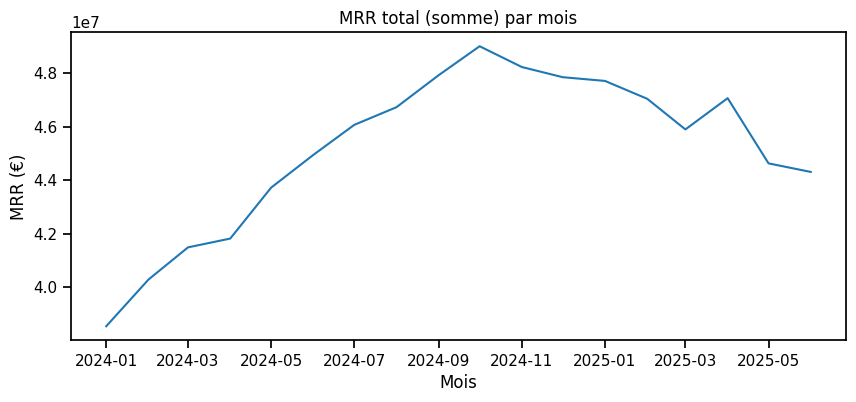

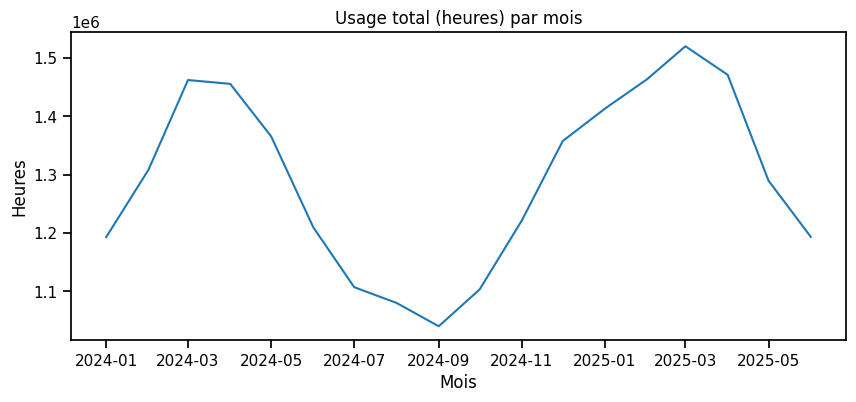

In [44]:
# 3.2 Série temporelle — MRR total et usage total
monthly = (df.groupby('date_mois')
           .agg(mrr_total=('mrr_eur','sum'),
                usage_total=('heures_utilisation','sum'),
                tickets_total=('nb_tickets_support','sum'))
           .reset_index())

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(monthly['date_mois'], monthly['mrr_total'])
ax.set_title('MRR total (somme) par mois')
ax.set_xlabel('Mois')
ax.set_ylabel('MRR (€)')
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(monthly['date_mois'], monthly['usage_total'])
ax.set_title('Usage total (heures) par mois')
ax.set_xlabel('Mois')
ax.set_ylabel('Heures')
plt.show()


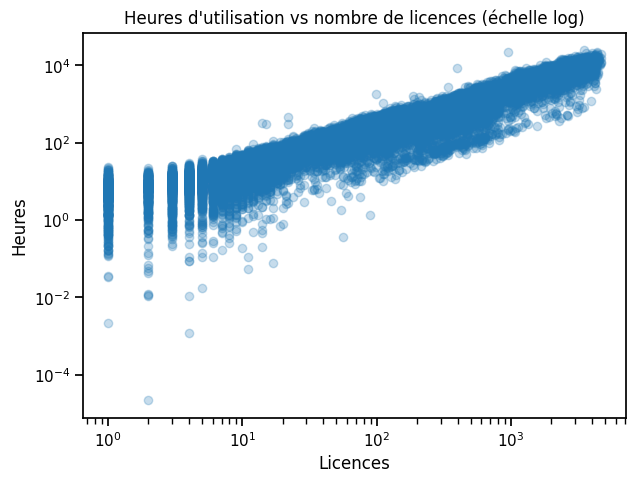

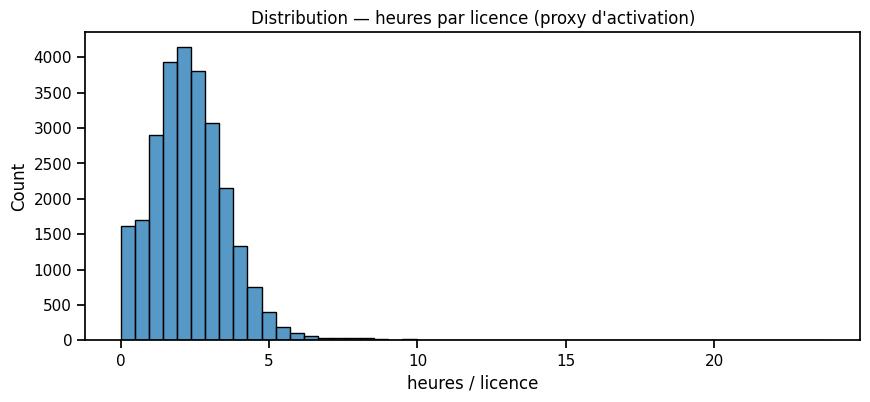

In [45]:
# 3.3 Usage vs licences : sous-exposition potentielle
plt.figure(figsize=(7,5))
plt.scatter(df['nb_licences'], df['heures_utilisation'], alpha=0.25)
plt.xscale('log')
plt.yscale('log')
plt.title("Heures d'utilisation vs nombre de licences (échelle log)")
plt.xlabel('Licences')
plt.ylabel('Heures')
plt.show()

# Ratio d'activation simple (heures / licences)
df['heures_par_licence'] = df['heures_utilisation'] / df['nb_licences'].replace(0, np.nan)
plt.figure(figsize=(10,4))
sns.histplot(df['heures_par_licence'].dropna(), bins=50)
plt.title("Distribution — heures par licence (proxy d'activation)")
plt.xlabel('heures / licence')
plt.show()


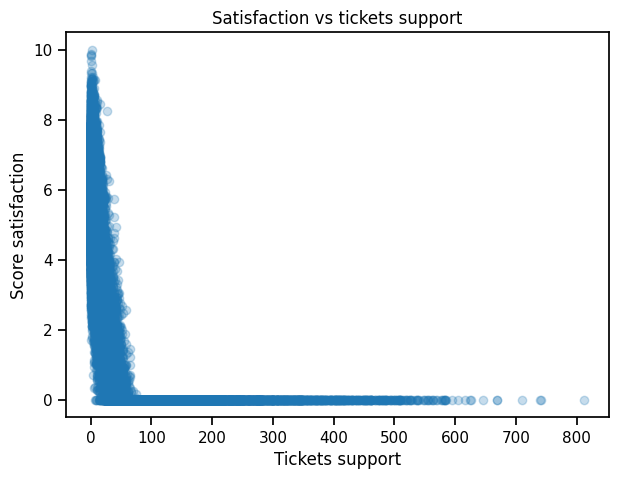

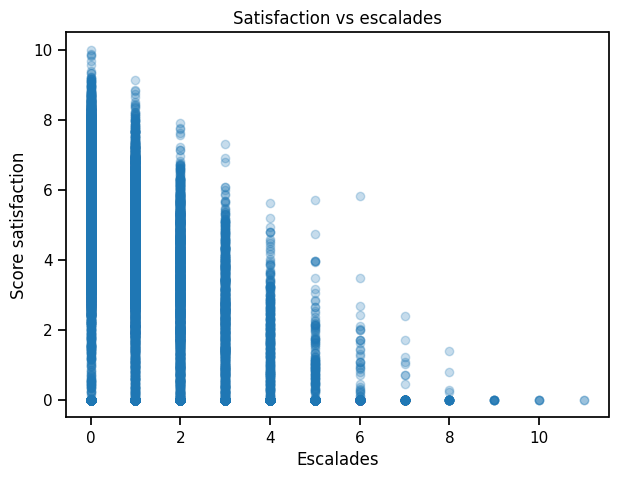

In [46]:
# 3.4 Support et satisfaction : hypothèse "plus d'incidents => satisfaction baisse"
plt.figure(figsize=(7,5))
plt.scatter(df['nb_tickets_support'], df['score_satisfaction'], alpha=0.25)
plt.title('Satisfaction vs tickets support')
plt.xlabel('Tickets support')
plt.ylabel('Score satisfaction')
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df['nb_escalades'], df['score_satisfaction'], alpha=0.25)
plt.title('Satisfaction vs escalades')
plt.xlabel('Escalades')
plt.ylabel('Score satisfaction')
plt.show()


### 3.5 Première lecture churn (niveau client)

Dans la dimension client, on dispose d’un **statut** et d’une **date de fin**.
- Pour l’analyse descriptive du churn, on peut les utiliser.
- Pour la **prédiction**, ces champs sont **interdits** (fuite d’information).


Taux de churn client (sur la fenêtre observée) : 15.67 %


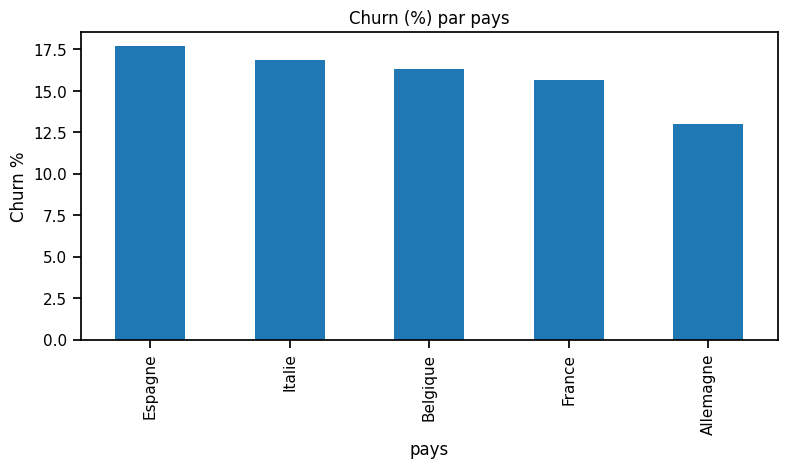

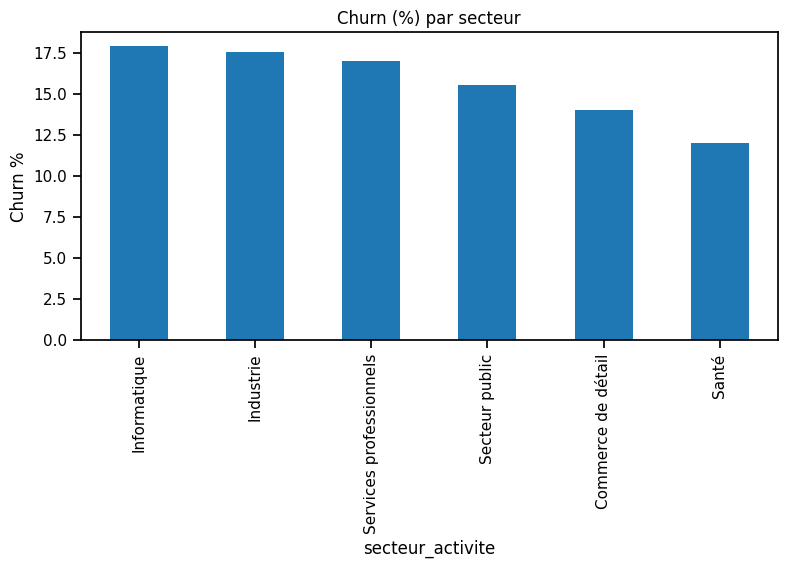

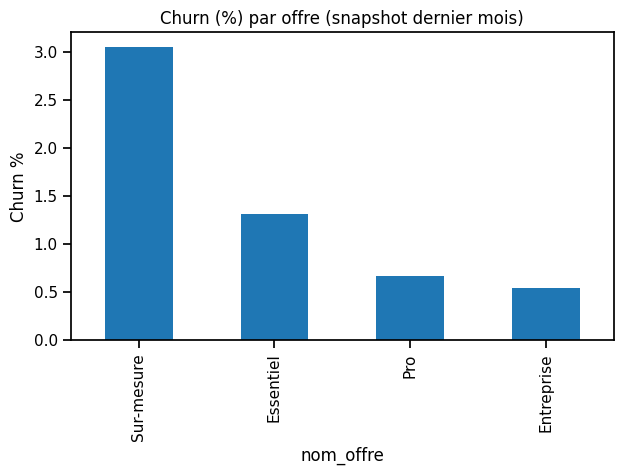

In [47]:
# 3.5 Churn descriptif (au niveau client)
dim_client['is_churned'] = (dim_client['statut_abonnement'] == 'Résilié').astype(int)
print('Taux de churn client (sur la fenêtre observée) :', round(dim_client['is_churned'].mean()*100, 2), '%')

# Churn par pays / secteur / offre "dernier mois"
last_month = df['date_mois'].max()
last_snapshot = (df[df['date_mois'] == last_month]
                 [['id_client','nom_offre','niveau_sla']]
                 .drop_duplicates('id_client'))

client_view = (dim_client
               .merge(last_snapshot, on='id_client', how='left'))

fig, ax = plt.subplots(figsize=(9,4))
(client_view.groupby('pays')['is_churned'].mean().sort_values(ascending=False)*100).plot(kind='bar', ax=ax)
ax.set_title('Churn (%) par pays')
ax.set_ylabel('Churn %')
plt.show()

fig, ax = plt.subplots(figsize=(9,4))
(client_view.groupby('secteur_activite')['is_churned'].mean().sort_values(ascending=False)*100).plot(kind='bar', ax=ax)
ax.set_title('Churn (%) par secteur')
ax.set_ylabel('Churn %')
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
(client_view.groupby('nom_offre')['is_churned'].mean().sort_values(ascending=False)*100).plot(kind='bar', ax=ax)
ax.set_title('Churn (%) par offre (snapshot dernier mois)')
ax.set_ylabel('Churn %')
plt.show()


## 4) Étape 3 — Segmentation (clustering)

### 4.1 Choix des variables de segmentation

Pour une segmentation **opérationnelle**, on cherche des axes stables et actionnables :
- **Valeur** : MRR, licences
- **Activation / usage** : heures, heures/licence
- **Coût de service** : tickets, escalades
- **Santé relationnelle** : satisfaction, retards de paiement

Nous allons construire un *profil client* en agrégeant l’historique observé.


In [48]:
# 4.2 Agrégation client (profil)
client_agg = (df.groupby('id_client')
              .agg(
                  mrr_moyen=('mrr_eur','mean'),
                  mrr_mediane=('mrr_eur','median'),
                  licences_moy=('nb_licences','mean'),
                  usage_moy_h=('heures_utilisation','mean'),
                  tickets_moy=('nb_tickets_support','mean'),
                  escalades_moy=('nb_escalades','mean'),
                  satisfaction_moy=('score_satisfaction','mean'),
                  retard_paiement_rate=('indicateur_retard_paiement','mean'),
                  nb_mois_observes=('id_date','nunique'),
              )
              .reset_index())

client_agg['heures_par_licence_moy'] = client_agg['usage_moy_h'] / client_agg['licences_moy'].replace(0, np.nan)

# Ajout variables dimension client (catégorielles et taille)
client_agg = (client_agg
              .merge(dim_client[['id_client','secteur_activite','pays','nb_employes']], on='id_client', how='left'))

display(client_agg.head())
print('Clients agrégés :', client_agg.shape[0])


,id_client,mrr_moyen,mrr_mediane,licences_moy,usage_moy_h,tickets_moy,escalades_moy,satisfaction_moy,retard_paiement_rate,nb_mois_observes,heures_par_licence_moy,secteur_activite,pays,nb_employes
0,002a4014-6765-42dc-b659-2b89cc4287ea,22999.883877,22824.948685,298.833333,492.079292,18.555556,1.444444,3.357055,0.055556,18,1.646668,Secteur public,France,2125
1,004b649c-0c4d-454b-9b21-e9f7ad1cca37,14780.758529,14861.498682,185.055556,571.104755,19.944444,1.777778,4.075809,0.166667,18,3.086126,Secteur public,Italie,948
2,004f9c97-ebe2-4ab8-b6c3-6e9e3d7da529,3157.826538,3176.882931,57.583333,127.787529,7.250000,0.333333,4.874261,0.166667,12,2.219176,Santé,France,150
3,006fd956-14dd-4898-931e-3f55ad5ca0d0,504.396199,359.119780,4.944444,15.402597,0.777778,0.111111,6.218590,0.277778,18,3.115132,Industrie,Allemagne,42
4,007a29e0-511e-4647-b911-cafe2f594dcd,1994.406688,2003.781977,28.055556,71.040645,5.111111,0.944444,5.446850,0.388889,18,2.532142,Santé,Italie,103


Clients agrégés : 1800


### 4.3 Préprocessing pour clustering

- On sélectionne des features numériques de comportement (on évite les identifiants).
- On impute les manquants (médiane) et on standardise (KMeans est sensible à l’échelle).


In [49]:
cluster_features = [
    'mrr_moyen','licences_moy','usage_moy_h','heures_par_licence_moy',
    'tickets_moy','escalades_moy','satisfaction_moy','retard_paiement_rate','nb_employes'
]

Xc = client_agg[cluster_features].copy()

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

cluster_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Xc_scaled = cluster_preprocess.fit_transform(Xc)
print('Matrice clustering :', Xc_scaled.shape)


Matrice clustering : (1800, 9)


### 4.4 Choix du nombre de clusters : coude (inertia) & silhouette

On calcule pour K=2..10 :
- **Inertia** : baisse forte puis plateau → « coude »
- **Silhouette** : cohésion/séparation (plus haut = mieux)

> En pratique, on croise les métriques **avec** la lisibilité business (3/4/5 segments).


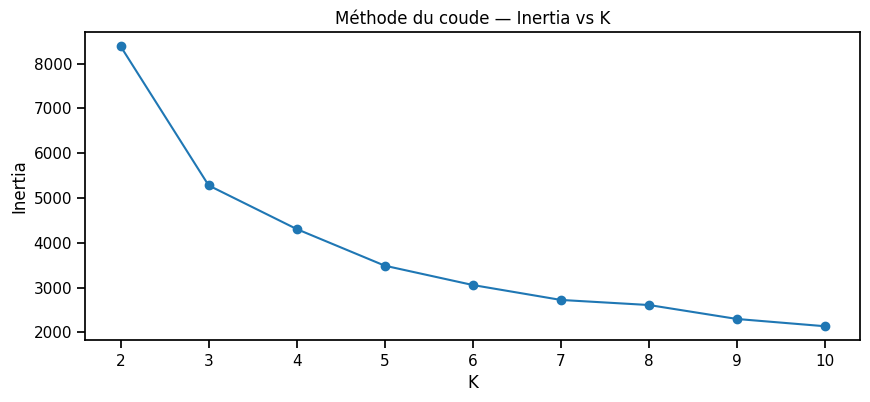

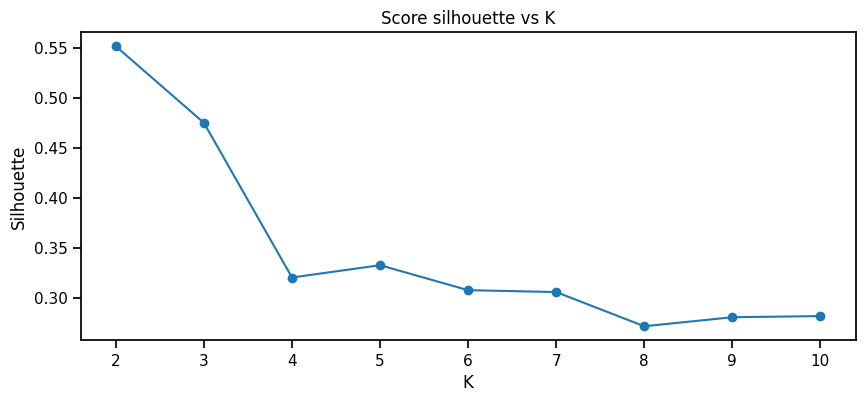

,k,silhouette,inertia
0,2,0.551477,8388.084301
1,3,0.475010,5279.460845
3,5,0.332913,3487.084623
2,4,0.320648,4304.971078
4,6,0.308005,3055.336861


In [50]:
ks = range(2, 11)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(Xc_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Xc_scaled, labels))

plt.figure(figsize=(10,4))
plt.plot(list(ks), inertias, marker='o')
plt.title('Méthode du coude — Inertia vs K')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

plt.figure(figsize=(10,4))
plt.plot(list(ks), silhouettes, marker='o')
plt.title('Score silhouette vs K')
plt.xlabel('K')
plt.ylabel('Silhouette')
plt.show()

# Aide à la décision : afficher les meilleures silhouettes
best = pd.DataFrame({'k': list(ks), 'silhouette': silhouettes, 'inertia': inertias}).sort_values('silhouette', ascending=False)
display(best.head(5))


### 4.5 Choix final de K (argumentation business)

Dans un contexte commercial / customer success, **4 segments** sont souvent un bon compromis :
- suffisamment différenciés pour piloter des actions
- pas trop nombreux pour rester opérationnels

> Nous fixons **K=4** (à ajuster si votre lecture des courbes coude/silhouette indique une alternative plus robuste).


In [51]:
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init='auto')
client_agg['cluster'] = kmeans.fit_predict(Xc_scaled)

client_agg['cluster'] = client_agg['cluster'].astype(int)
client_agg['cluster'].value_counts().sort_index()


cluster
0    569
1    382
2    714
3    135
Name: count, dtype: int64

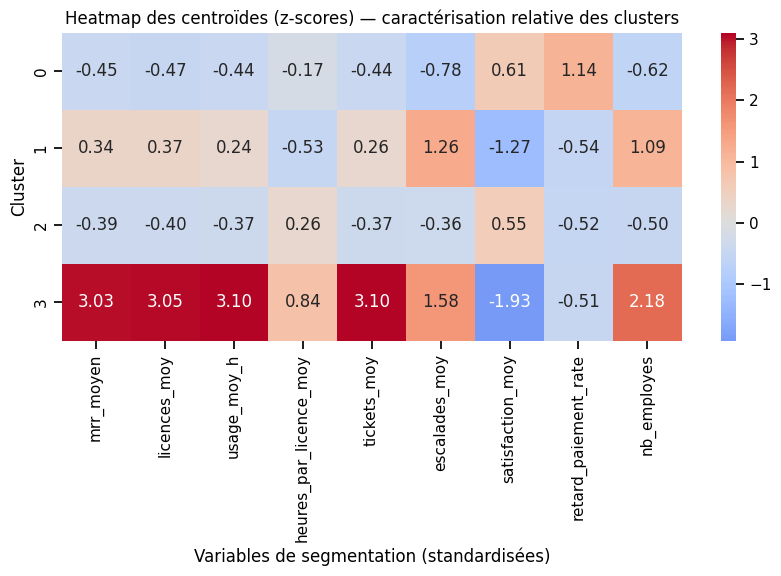

,mrr_moyen,licences_moy,usage_moy_h,heures_par_licence_moy,tickets_moy,escalades_moy,satisfaction_moy,retard_paiement_rate,nb_employes
cluster,,,,,,,,,
0,571.10,9.39,19.33,2.19,1.75,0.17,5.52,0.39,53.0
1,41897.35,516.22,983.53,1.89,38.52,2.09,1.28,0.11,4011.0
2,3648.24,61.21,149.36,2.54,6.55,0.50,5.46,0.17,238.0
3,205985.57,2335.79,6151.31,2.78,225.00,2.42,0.00,0.11,6641.0


In [52]:
# 4.6 Centroides (échelle d'origine) + heatmap (z-scores)

# Centroides sur données standardisées puis retour en "profil relatif" (z-score)
centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_features)

plt.figure(figsize=(10,4))
sns.heatmap(centroids_scaled, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap des centroïdes (z-scores) — caractérisation relative des clusters')
plt.xlabel('Variables de segmentation (standardisées)')
plt.ylabel('Cluster')
plt.show()

# Profil en unités métier (médianes par cluster, robuste aux outliers)
cluster_profile = (client_agg.groupby('cluster')[cluster_features]
                   .median()
                   .round(2))

display(cluster_profile)


### 4.7 Lecture métier des segments

On propose une lecture typique (à adapter selon les centroïdes) :
- **Segment 0 :** faible valeur / faible usage → activation, onboarding, éviter l’attrition silencieuse
- **Segment 1 :** valeur moyenne / usage élevé → potentiel d’upsell, proposer options SLA/support
- **Segment 2 :** forte valeur / support élevé → prioriser CSM senior, prévention incidents, optimisation support
- **Segment 3 :** forte valeur / forte satisfaction → comptes stratégiques, expansion, co-innovation

> L’objectif n’est pas la « vérité absolue », mais une segmentation **exploitable** (plan d’action par segment).


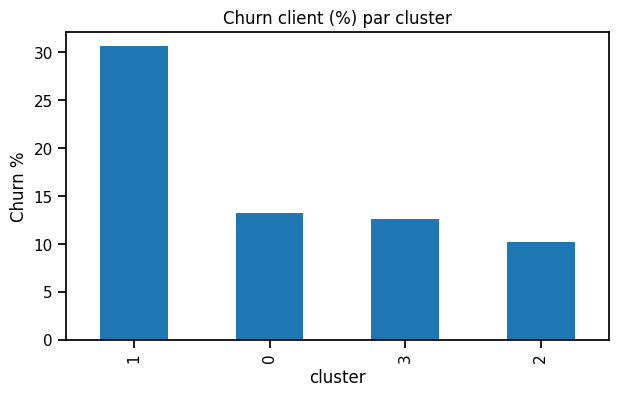

,MRR_mediane,Churn_%
cluster,,
0,571.104097,13.18
1,41897.346660,30.63
2,3648.237680,10.22
3,205985.571377,12.59


In [53]:
# 4.8 Segmentation vs churn (priorisation)

# Churn descriptif au niveau client
client_churn = dim_client[['id_client','statut_abonnement']].copy()
client_churn['is_churned'] = (client_churn['statut_abonnement']=='Résilié').astype(int)

seg_view = client_agg.merge(client_churn[['id_client','is_churned']], on='id_client', how='left')

churn_by_cluster = (seg_view.groupby('cluster')['is_churned'].mean()*100).round(2)

plt.figure(figsize=(7,4))
churn_by_cluster.sort_values(ascending=False).plot(kind='bar')
plt.title('Churn client (%) par cluster')
plt.ylabel('Churn %')
plt.show()

# Matrice "valeur" (MRR) vs "risque" (churn)
value_by_cluster = seg_view.groupby('cluster')['mrr_moyen'].median()

summary = pd.DataFrame({
    'MRR_mediane': value_by_cluster,
    'Churn_%': churn_by_cluster
}).sort_index()

display(summary)


## 5) Étape 4 — Préparation supervisée (Pipeline sklearn)

### 5.1 Construction de la cible churn à horizon 6 mois

**Définition** : au mois d’observation *t*, la cible vaut 1 si le client résilie **dans les 6 mois** suivants.

**Censure** : si *t + 6 mois* dépasse la fenêtre d’observation, on ne peut pas dire « non churn » → on exclut ces mois (rigueur demandée).


In [54]:
# 5.1 Dataset labelisable (on coupe les derniers mois : max_date - 6 mois)
max_month = df['date_mois'].max()
label_cutoff = (max_month - pd.DateOffset(months=6)).replace(day=1)

df_sup = df[df['date_mois'] <= label_cutoff].copy()

# Horizon de 6 mois : fin de mois
horizon_end = df_sup['date_mois'] + pd.DateOffset(months=6) + pd.offsets.MonthEnd(0)

df_sup['churn_6m'] = ((df_sup['date_fin_abonnement'].notna()) & (df_sup['date_fin_abonnement'] <= horizon_end)).astype(int)

# Ancienneté au mois t
months_since_start = (df_sup['date_mois'].dt.year - df_sup['date_debut_abonnement'].dt.year)*12                     + (df_sup['date_mois'].dt.month - df_sup['date_debut_abonnement'].dt.month)

df_sup['anciennete_mois'] = months_since_start.clip(lower=0)

print("Période labelisable jusqu'au :", label_cutoff.date())
print('Lignes supervisées :', df_sup.shape[0])
print('Taux positif (churn_6m) :', round(df_sup['churn_6m'].mean()*100, 2), '%')


Période labelisable jusqu'au : 2024-12-01
Lignes supervisées : 17707
Taux positif (churn_6m) : 8.08 %


### 5.2 Features disponibles au mois t (anti-leakage)

On **exclut** :
- `statut_abonnement`, `date_fin_abonnement` (information future)
- `segment_reference` (segment « vérité terrain » fourni à des fins pédagogiques)

On conserve : usage, support, satisfaction, paiement, caractéristiques client, offre, calendrier, ancienneté.


In [55]:
target = 'churn_6m'

num_features = [
    'mrr_eur','nb_licences','heures_utilisation','nb_tickets_support','nb_escalades',
    'score_satisfaction','indicateur_retard_paiement','nb_employes',
    'prix_mensuel_base_eur','prix_par_licence_eur','remise_volume_max_pct',
    'anciennete_mois','mois','trimestre'
]

cat_features = ['secteur_activite','pays','nom_offre','niveau_sla']

X = df_sup[num_features + cat_features].copy()
y = df_sup[target].copy()
groups = df_sup['id_client'].copy()  # éviter fuite entre mois du même client

# Train/test split par client (GroupShuffleSplit)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

def eval_classif(name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    auc = roc_auc_score(y_true, y_proba)
    ap  = average_precision_score(y_true, y_proba)
    cm  = confusion_matrix(y_true, y_pred)

    print(f"=== {name} ===")
    print(f"ROC AUC : {auc:.3f} | PR AUC : {ap:.3f} | pos_rate_test : {y_true.mean():.3f}")
    print(f"Confusion matrix (threshold={threshold:.2f}) :")
    print(cm)
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3))

print('Train rows:', X_train.shape[0], ' | Test rows:', X_test.shape[0])

Train rows: 14214  | Test rows: 3493


### 5.3 Pipeline sklearn (imputation + encodage + standardisation)

On construit un pipeline **reproductible** :
- Numériques : imputation médiane + standardisation
- Catégorielles : imputation + one-hot

Ce pipeline est la base des comparaisons de modèles.


In [56]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)


## 6) Étape 5 — Modélisation : pourquoi un modèle linéaire est insuffisant, puis boosting

### 6.1 Baseline linéaire (logistic regression)

Un modèle linéaire suppose un lien (quasi) additif entre features et risque de churn.
Or, en churn SaaS, les effets sont souvent **non-linéaires** :
- seuils (usage « trop bas »)
- interactions (tickets élevés **et** satisfaction basse)
- asymétries (retard de paiement rare mais très discriminant)

Nous utilisons une régression logistique comme baseline.


In [57]:
log_reg = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_reg.fit(X_train, y_train)
proba_lr = log_reg.predict_proba(X_test)[:,1]

eval_classif('Baseline — Logistic Regression (linéaire)', y_test, proba_lr, threshold=0.5)


=== Baseline — Logistic Regression (linéaire) ===
ROC AUC : 0.644 | PR AUC : 0.131 | pos_rate_test : 0.083
Confusion matrix (threshold=0.50) :
[[2193 1009]
 [ 134  157]]

Classification report:
              precision    recall  f1-score   support

           0      0.942     0.685     0.793      3202
           1      0.135     0.540     0.216       291

    accuracy                          0.673      3493
   macro avg      0.539     0.612     0.504      3493
weighted avg      0.875     0.673     0.745      3493



### 6.2 Gradient Boosting (sklearn)

On entraîne un modèle non-linéaire basé sur des arbres.
Pour limiter les coûts, on encode les catégories en **ordinal** (acceptable ici pour un benchmark), puis on ajuste quelques hyperparamètres.


In [58]:
# Préprocessing alternatif (ordinal) pour arbres sklearn
ordinal_preprocess = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), cat_features)
    ]
)

gb_clf = Pipeline(steps=[
    ('preprocess', ordinal_preprocess),
    ('model', GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    'model__n_estimators': [150, 300],
    'model__learning_rate': [0.03, 0.06],
    'model__max_depth': [2, 3]
}

cv = GroupKFold(n_splits=3)

grid_gb = GridSearchCV(
    gb_clf,
    param_grid=param_grid_gb,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=0
)

grid_gb.fit(X_train, y_train, **{'groups': df_sup.iloc[train_idx]['id_client']})
print('Best GB params:', grid_gb.best_params_)
print('Best CV ROC AUC:', round(grid_gb.best_score_, 3))

best_gb = grid_gb.best_estimator_
proba_gb = best_gb.predict_proba(X_test)[:,1]

eval_classif('Gradient Boosting (sklearn)', y_test, proba_gb, threshold=0.5)


Best GB params: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 150}
Best CV ROC AUC: 0.644
=== Gradient Boosting (sklearn) ===
ROC AUC : 0.646 | PR AUC : 0.153 | pos_rate_test : 0.083
Confusion matrix (threshold=0.50) :
[[3202    0]
 [ 291    0]]

Classification report:
              precision    recall  f1-score   support

           0      0.917     1.000     0.957      3202
           1      0.000     0.000     0.000       291

    accuracy                          0.917      3493
   macro avg      0.458     0.500     0.478      3493
weighted avg      0.840     0.917     0.877      3493



### 6.3 XGBoost + GridSearchCV

XGBoost est souvent très performant sur des données tabulaires avec non-linéarités.
Nous effectuons un *GridSearchCV* (grille volontairement raisonnable pour un cadre pédagogique).


In [59]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

xgb_pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', xgb)
])

param_grid_xgb = {
    'model__n_estimators': [300, 600],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.03, 0.06],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__reg_lambda': [1.0, 3.0]
}

grid_xgb = GridSearchCV(
    xgb_pipe,
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=0
)

grid_xgb.fit(X_train, y_train, **{'groups': df_sup.iloc[train_idx]['id_client']})
print('Best XGB params:', grid_xgb.best_params_)
print('Best CV ROC AUC:', round(grid_xgb.best_score_, 3))

best_xgb = grid_xgb.best_estimator_
proba_xgb = best_xgb.predict_proba(X_test)[:,1]

eval_classif('XGBoost', y_test, proba_xgb, threshold=0.5)


Best XGB params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__reg_lambda': 3.0, 'model__subsample': 0.8}
Best CV ROC AUC: 0.648
=== XGBoost ===
ROC AUC : 0.653 | PR AUC : 0.134 | pos_rate_test : 0.083
Confusion matrix (threshold=0.50) :
[[3202    0]
 [ 291    0]]

Classification report:
              precision    recall  f1-score   support

           0      0.917     1.000     0.957      3202
           1      0.000     0.000     0.000       291

    accuracy                          0.917      3493
   macro avg      0.458     0.500     0.478      3493
weighted avg      0.840     0.917     0.877      3493



### 6.4 Feature importance → insights business

Objectif : passer d’un score à une **lecture causale plausible** (avec prudence).

On récupère :
- les noms de features (après one-hot)
- les importances XGBoost
- une agrégation par variable d’origine (MRR, satisfaction, tickets, etc.)

> Limite : l’importance n’est pas une causalité, mais un **indice** pour guider l’investigation métier.


,feature,importance
28,cat__nom_offre_Sur-mesure,0.077870
5,num__score_satisfaction,0.064884
14,cat__secteur_activite_Commerce de détail,0.052936
17,cat__secteur_activite_Santé,0.048102
7,num__nb_employes,0.044162
0,num__mrr_eur,0.041849
23,cat__pays_France,0.039794
25,cat__nom_offre_Entreprise,0.037909
27,cat__nom_offre_Pro,0.037671
1,num__nb_licences,0.035762


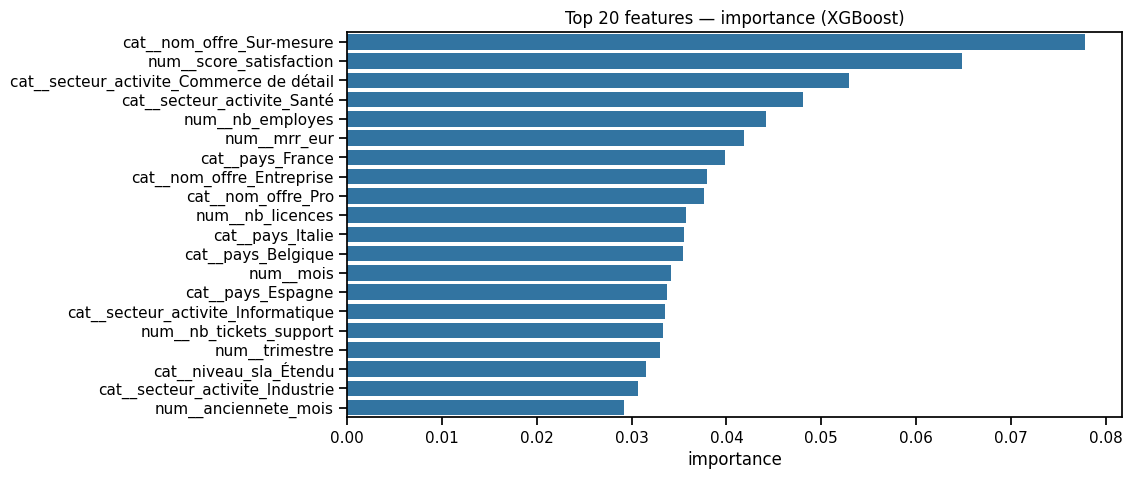

,base_feature,importance
0,secteur,0.204972
1,pays,0.165160
2,nom,0.153450
3,nb,0.129846
4,score,0.064884
5,prix,0.058064
6,mrr,0.041849
7,mois,0.034168
8,trimestre,0.033019
9,niveau,0.031522


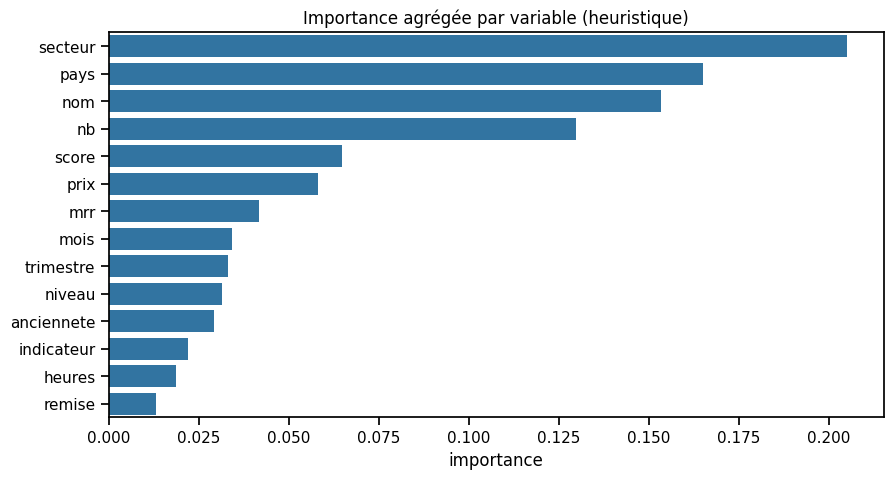

In [60]:
# Récupération des noms de features après preprocessing
pre = best_xgb.named_steps['preprocess']

# get_feature_names_out est disponible sur ColumnTransformer (sklearn >= 1.0)
feature_names = pre.get_feature_names_out()

importances = best_xgb.named_steps['model'].feature_importances_
fi = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi = fi.sort_values('importance', ascending=False)

display(fi.head(20))

plt.figure(figsize=(10,5))
sns.barplot(data=fi.head(20), x='importance', y='feature')
plt.title('Top 20 features — importance (XGBoost)')
plt.ylabel('')
plt.show()

# Agrégation par "variable d'origine" (approx) : num__xxx ou cat__xxx_yyy
fi['base_feature'] = fi['feature'].str.replace(r'^num__', '', regex=True)
fi['base_feature'] = fi['base_feature'].str.replace(r'^cat__', '', regex=True)
fi['base_feature'] = fi['base_feature'].str.split('_').str[0]  # heuristique simple

fi_agg = (fi.groupby('base_feature')['importance'].sum()
          .sort_values(ascending=False)
          .reset_index())

display(fi_agg.head(15))

plt.figure(figsize=(10,5))
sns.barplot(data=fi_agg.head(15), x='importance', y='base_feature')
plt.title('Importance agrégée par variable (heuristique)')
plt.ylabel('')
plt.show()


## 7) Conclusion business (synthèse actionnable)

### 7.1 Synthèse Segmentation
- Décrire 4 segments avec **axes** : valeur (MRR), activation (usage/licence), coût support, satisfaction / paiement.
- Croiser segments × churn pour une **priorisation** :
  - *High value / high risk* : plans de rétention proactifs (CSM senior, QBR, SLA, roadmap)
  - *Low value / high risk* : activation light-touch (onboarding, in-app guidance) ou stratégie de dépriorisation
  - *High value / low risk* : upsell/cross-sell, expansion (licences, options)
  - *Support-heavy* : optimisation (self-service, knowledge base, amélioration produit)

### 7.2 Synthèse Churn & leviers
Les signaux typiques à investiguer (selon importances et EDA) :
- baisse d’usage / faible activation (heures/licence)
- augmentation tickets / escalades + baisse satisfaction
- retards de paiement (signal fort)
- faible ancienneté (risque early churn)

### 7.3 Prochaines étapes (professionnalisation)
- enrichir les features temporelles : tendances (Δ usage), rolling mean (3 mois), événements incidents
- calibrer le seuil opérationnel (optimiser recall sur churn)
- industrialiser : monitoring dérive, réentraînement mensuel, boucle de feedback Customer Success
